# 09_v2 - Team Classification su BoT-SORT + ReID

## Obiettivo

Associare ciascun player track ad una delle due squadre utilizzando
principalmente le informazioni visive della divisa.

La classificazione viene effettuata a livello di track e non di singolo frame,
in modo da sfruttare più osservazioni dello stesso giocatore e ridurre
l'effetto di:

- illuminazione;
- motion blur;
- occlusioni;
- pose differenti.

Pipeline:

BoT-SORT + ReID tracks
→ player crop
→ torso crop
→ color features
→ aggregation per track
→ clustering
→ team label

In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

/Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [6]:
from pathlib import Path

DRIVE_ROOT = Path(
    "/Users/marcodalbis/Library/CloudStorage/"
    "GoogleDrive-marco.dalbis@gmail.com/"
    "Il mio Drive/"
    "basketball-thesis"
)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

FRAMES_DIR = (
    DRIVE_ROOT
    / "datasets"
    / "sportsmot"
    / "val"
    / SEQUENCE_NAME
    / "img1"
)

TRACKS_CSV = (
    DRIVE_ROOT
    / "experiments"
    / "sam2_tracking"
    / f"{SEQUENCE_NAME}_tracks.csv"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "sam2_tracking"
    / "team_classification"
    / SEQUENCE_NAME
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Frames:", FRAMES_DIR.exists())
print("Tracks:", TRACKS_CSV.exists())
print("Output:", OUTPUT_DIR)

Frames: True
Tracks: True
Output: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/botsort_reid/team_classification/v_00HRwkvvjtQ_c001


Caricamento Tracking

In [3]:
if torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.14.0
Device: mps


In [4]:
print(
    tracks_df.columns.tolist()
)

['frame', 'track_id', 'x1', 'y1', 'x2', 'y2', 'confidence', 'class_id']


Distribuzione Colonne Track

In [5]:
track_counts = (
    tracks_df["track_id"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

display(
    track_counts.to_frame(
        "observations"
    )
)

print(
    "Median track length:",
    track_counts.median()
)

,observations
track_id,
3,1155
4,1141
21,1011
0,897
10,808
14,687
31,684
18,658
1,639


Median track length: 169.0


## Estrazione dei player crop

Per ogni bounding box del tracker viene estratta l'immagine del giocatore.

Per la classificazione della squadra verrà utilizzata principalmente la
regione superiore del corpo, poiché contiene la parte più informativa
della divisa e riduce l'influenza di parquet, scarpe e sfondo.

Funzione player Crop

In [6]:
def extract_player_crop(
    frame,
    x1,
    y1,
    x2,
    y2,
):

    h, w = frame.shape[:2]

    x1 = max(
        0,
        int(round(x1))
    )

    y1 = max(
        0,
        int(round(y1))
    )

    x2 = min(
        w,
        int(round(x2))
    )

    y2 = min(
        h,
        int(round(y2))
    )

    if x2 <= x1 or y2 <= y1:
        return None

    crop = frame[
        y1:y2,
        x1:x2
    ]

    return crop

Regione Torso

In [7]:
def extract_torso(player_crop):

    if player_crop is None:
        return None

    h, w = player_crop.shape[:2]

    if h < 20 or w < 10:
        return None

    y1 = int(0.18 * h)
    y2 = int(0.52 * h)

    x1 = int(0.25 * w)
    x2 = int(0.75 * w)

    torso = player_crop[
        y1:y2,
        x1:x2
    ]

    if torso.size == 0:
        return None

    return torso

Selezione Track Lungo

In [8]:
TEST_TRACK_ID = int(
    track_counts.index[0]
)

test_track = (
    tracks_df[
        tracks_df["track_id"]
        == TEST_TRACK_ID
    ]
    .sort_values("frame")
)

sample_row = (
    test_track
    .iloc[
        len(test_track) // 2
    ]
)

print(
    "Track ID:",
    TEST_TRACK_ID
)

display(
    sample_row.to_frame(
        "value"
    )
)

Track ID: 3


,value
frame,583.000000
track_id,3.000000
x1,496.985474
y1,174.275635
x2,557.576904
y2,350.604309
confidence,0.753710
class_id,0.000000


Visualizzazione player e torso

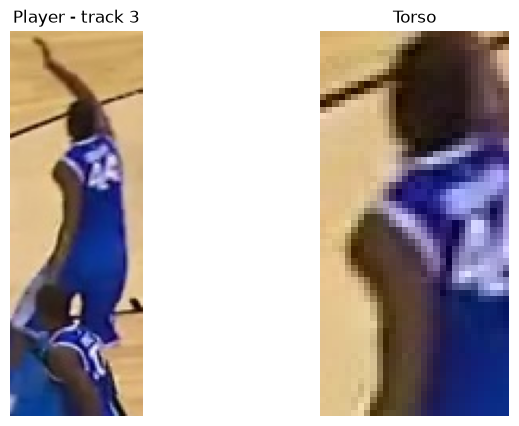

In [9]:
frame_number = int(
    sample_row["frame"]
)

frame_path = (
    FRAMES_DIR
    / f"{frame_number:06d}.jpg"
)

frame = cv2.imread(
    str(frame_path)
)

assert frame is not None

player_crop = extract_player_crop(
    frame,
    sample_row["x1"],
    sample_row["y1"],
    sample_row["x2"],
    sample_row["y2"],
)

torso_crop = extract_torso(
    player_crop
)

plt.figure(
    figsize=(8, 5)
)

plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    cv2.cvtColor(
        player_crop,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Player - track {TEST_TRACK_ID}"
)

plt.axis("off")

plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    cv2.cvtColor(
        torso_crop,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Torso")

plt.axis("off")

plt.show()

Feature Colore

In [10]:
def color_features(torso):

    if torso is None or torso.size == 0:
        return None

    hsv = cv2.cvtColor(
        torso,
        cv2.COLOR_BGR2HSV
    )

    lab = cv2.cvtColor(
        torso,
        cv2.COLOR_BGR2LAB
    )

    hsv_pixels = hsv.reshape(-1, 3)
    lab_pixels = lab.reshape(-1, 3)

    H = hsv_pixels[:, 0]
    S = hsv_pixels[:, 1]
    V = hsv_pixels[:, 2]

    L = lab_pixels[:, 0]

    # Statistiche robuste
    hsv_median = np.median(
        hsv_pixels,
        axis=0
    )

    lab_median = np.median(
        lab_pixels,
        axis=0
    )

    hsv_q25 = np.percentile(
        hsv_pixels,
        25,
        axis=0
    )

    hsv_q75 = np.percentile(
        hsv_pixels,
        75,
        axis=0
    )

    # Feature aggiuntive per maglie chiare/scure
    white_ratio = np.mean(
        (S < 60)
        & (V > 150)
    )

    bright_ratio = np.mean(
        V > 170
    )

    dark_ratio = np.mean(
        V < 90
    )

    low_saturation_ratio = np.mean(
        S < 70
    )

    mean_saturation = np.mean(S)
    mean_value = np.mean(V)
    mean_lightness = np.mean(L)

    features = np.concatenate([
        hsv_median,
        lab_median,
        hsv_q25,
        hsv_q75,
        [
            white_ratio,
            bright_ratio,
            dark_ratio,
            low_saturation_ratio,
            mean_saturation,
            mean_value,
            mean_lightness,
        ]
    ])

    return features.astype(
        np.float32
    )

Campionamento Temporale

In [11]:
MAX_SAMPLES_PER_TRACK = 25

MIN_BOX_HEIGHT = 60
MIN_BOX_WIDTH = 20

MIN_CONFIDENCE = 0.50

Estrazione Feature da tutti i track

In [12]:
feature_rows = []

unique_tracks = sorted(
    tracks_df["track_id"].unique()
)

for track_id in unique_tracks:

    track_data = (
        tracks_df[
            tracks_df["track_id"]
            == track_id
        ]
        .sort_values("frame")
        .copy()
    )

    if len(track_data) == 0:
        continue

    if len(track_data) > MAX_SAMPLES_PER_TRACK:

        indices = np.linspace(
            0,
            len(track_data) - 1,
            MAX_SAMPLES_PER_TRACK
        ).astype(int)

        track_data = (
            track_data
            .iloc[indices]
        )

    for _, row in track_data.iterrows():

        if row["confidence"] < MIN_CONFIDENCE:
            continue

        box_width = (
            row["x2"]
            - row["x1"]
        )

        box_height = (
            row["y2"]
            - row["y1"]
        )

        if box_width < MIN_BOX_WIDTH:
            continue

        if box_height < MIN_BOX_HEIGHT:
            continue

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        player_crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        torso = extract_torso(
            player_crop
        )

        features = color_features(
            torso
        )

        if features is None:
            continue

        feature_rows.append({
            "track_id": int(track_id),
            "frame": frame_number,
            **{
                f"f{i}": float(value)
                for i, value
                in enumerate(features)
            }
        })

feature_df = pd.DataFrame(
    feature_rows
)

print(
    "Feature observations:",
    len(feature_df)
)

print(
    "Tracks represented:",
    feature_df["track_id"].nunique()
)

display(
    feature_df.head()
)

Feature observations: 637
Tracks represented: 34


,track_id,frame,f0,f1,f2,f3,f4,f5,f6,f7,...,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18
0,0,1,132.0,58.0,169.0,156.0,141.0,122.0,16.0,44.0,...,147.00,105.0,213.0,0.422989,0.492529,0.209195,0.608333,81.654594,160.609192,140.738220
1,0,38,132.0,59.0,187.5,168.0,140.0,122.0,18.0,46.0,...,145.00,125.0,212.0,0.411932,0.634334,0.088474,0.572646,81.855110,172.576294,152.066971
2,0,77,18.0,128.0,194.0,170.0,137.0,159.0,17.0,72.0,...,134.25,136.0,208.0,0.146655,0.614923,0.159949,0.243568,109.543312,166.773163,144.649658
3,0,115,153.0,43.0,174.0,162.0,141.0,123.0,138.0,37.0,...,165.00,56.0,190.0,0.666383,0.547234,0.061277,0.879149,49.779575,165.068939,151.497879
4,0,153,113.0,126.0,91.0,48.0,137.0,122.5,16.0,84.0,...,118.00,194.0,113.0,0.066764,0.179017,0.484226,0.179751,133.912323,106.107117,78.217171


Aggregazione Frame

In [13]:
feature_columns = [
    column
    for column in feature_df.columns
    if column.startswith("f")
]

track_features = (
    feature_df
    .groupby("track_id")[
        feature_columns
    ]
    .median()
)

track_features[
    "num_samples"
] = (
    feature_df
    .groupby("track_id")
    .size()
)

Filtra Track poco rappresentativi

In [14]:
MIN_FEATURE_SAMPLES = 3

valid_track_features = (
    track_features[
        track_features["num_samples"]
        >= MIN_FEATURE_SAMPLES
    ]
    .copy()
)

print(
    "Tracks used for clustering:",
    len(valid_track_features)
)

Tracks used for clustering: 30


## Clusteriong

Standardizzazione

In [15]:
REFEREE_TRACK_IDS = []

player_track_features = (
    valid_track_features[
        ~valid_track_features.index.isin(
            REFEREE_TRACK_IDS
        )
    ]
    .copy()
)

print(
    "Track totali:",
    len(valid_track_features)
)

print(
    "Referee esclusi:",
    REFEREE_TRACK_IDS
)

print(
    "Player track rimasti:",
    len(player_track_features)
)

Track totali: 30
Referee esclusi: []
Player track rimasti: 30


In [16]:
X = (
    player_track_features[
        feature_columns
    ]
    .values
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print(
    X_scaled.shape
)

(30, 20)


K-means

In [17]:
N_CLUSTERS = 2

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=50,
)

cluster_labels = kmeans.fit_predict(
    X_scaled
)

player_track_features[
    "cluster"
] = cluster_labels

display(
    player_track_features[
        ["num_samples", "cluster"]
    ]
    .sort_values(
        "cluster"
    )
)

,num_samples,cluster
track_id,,
0,25,0
49,8,0
44,4,0
31,25,0
30,3,0
25,24,0
24,7,0
13,22,0
9,25,0


In [18]:
track_vote_rows = []

for _, row in feature_df.iterrows():

    track_id = int(row["track_id"])

    if track_id not in player_track_features.index:
        continue

    features = (
        row[feature_columns]
        .values
        .astype(float)
        .reshape(1, -1)
    )

    features_scaled = scaler.transform(
        features
    )

    frame_cluster = int(
        kmeans.predict(
            features_scaled
        )[0]
    )

    track_vote_rows.append({
        "track_id": track_id,
        "frame": int(row["frame"]),
        "frame_cluster": frame_cluster,
    })

frame_votes_df = pd.DataFrame(
    track_vote_rows
)

display(
    frame_votes_df.head()
)

,track_id,frame,frame_cluster
0,0,1,1
1,0,38,1
2,0,77,1
3,0,115,1
4,0,153,0


In [19]:
track_ids_to_check = (
    player_track_features
    .sort_values(
        "num_samples",
        ascending=False
    )
    .head(5)
    .index
    .tolist()
)

print(
    "Track da controllare:",
    track_ids_to_check
)

for track_id in track_ids_to_check:

    votes = (
        frame_votes_df[
            frame_votes_df["track_id"] == track_id
        ]["frame_cluster"]
        .value_counts()
        .sort_index()
    )

    print(
        f"\nTrack {track_id}"
    )

    print(votes)

Track da controllare: [0, 14, 54, 53, 52]

Track 0
frame_cluster
0    19
1     6
Name: count, dtype: int64

Track 14
frame_cluster
0     4
1    21
Name: count, dtype: int64

Track 54
frame_cluster
0     3
1    22
Name: count, dtype: int64

Track 53
frame_cluster
1    25
Name: count, dtype: int64

Track 52
frame_cluster
1    25
Name: count, dtype: int64


In [20]:
track_team_consistency = (
    frame_votes_df
    .groupby(
        [
            "track_id",
            "frame_cluster"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for cluster_id in [0, 1]:

    if cluster_id not in track_team_consistency.columns:
        track_team_consistency[
            cluster_id
        ] = 0

track_team_consistency[
    "total"
] = (
    track_team_consistency[
        [0, 1]
    ]
    .sum(
        axis=1
    )
)

track_team_consistency[
    "ratio_cluster_0"
] = (
    track_team_consistency[0]
    / track_team_consistency["total"]
)

track_team_consistency[
    "ratio_cluster_1"
] = (
    track_team_consistency[1]
    / track_team_consistency["total"]
)

track_team_consistency[
    "max_team_ratio"
] = (
    track_team_consistency[
        [
            "ratio_cluster_0",
            "ratio_cluster_1"
        ]
    ]
    .max(
        axis=1
    )
)

track_team_consistency[
    "ambiguous"
] = (
    track_team_consistency[
        "max_team_ratio"
    ]
    < 0.80
)

display(
    track_team_consistency.sort_values(
        "max_team_ratio"
    )
)

frame_cluster,0,1,total,ratio_cluster_0,ratio_cluster_1,max_team_ratio,ambiguous
track_id,,,,,,,
21,11,14,25,0.440000,0.560000,0.560000,True
2,18,7,25,0.720000,0.280000,0.720000,True
8,7,18,25,0.280000,0.720000,0.720000,True
0,19,6,25,0.760000,0.240000,0.760000,True
19,5,19,24,0.208333,0.791667,0.791667,True
48,3,13,16,0.187500,0.812500,0.812500,False
14,4,21,25,0.160000,0.840000,0.840000,False
13,19,3,22,0.863636,0.136364,0.863636,False
1,21,3,24,0.875000,0.125000,0.875000,False


In [21]:
AMBIGUOUS_THRESHOLD = 0.80

ambiguous_tracks = (
    track_team_consistency[
        track_team_consistency[
            "max_team_ratio"
        ]
        < AMBIGUOUS_THRESHOLD
    ]
    .index
    .tolist()
)

print(
    "Ambiguous tracks:",
    ambiguous_tracks
)

Ambiguous tracks: [0, 2, 8, 19, 21]


## Visualizzazione PCA
Serve solo a capire se i gruppi sono effettivamente separabili.
### PCA

In [22]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "track_id": player_track_features.index,
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "cluster": cluster_labels,
})

display(
    pca_df
)

,track_id,pc1,pc2,cluster
0,0,-4.151138,0.884199,0
1,1,-3.512465,0.415420,0
2,2,-2.875914,3.414573,0
3,3,-3.263695,1.027131,0
4,4,-4.595246,1.771960,0
5,5,-0.198519,2.907207,1
6,6,1.193975,0.961406,1
7,7,4.269955,1.309021,1
8,8,2.470397,0.430978,1
9,9,-4.178616,1.424884,0


### Grafico Cluster

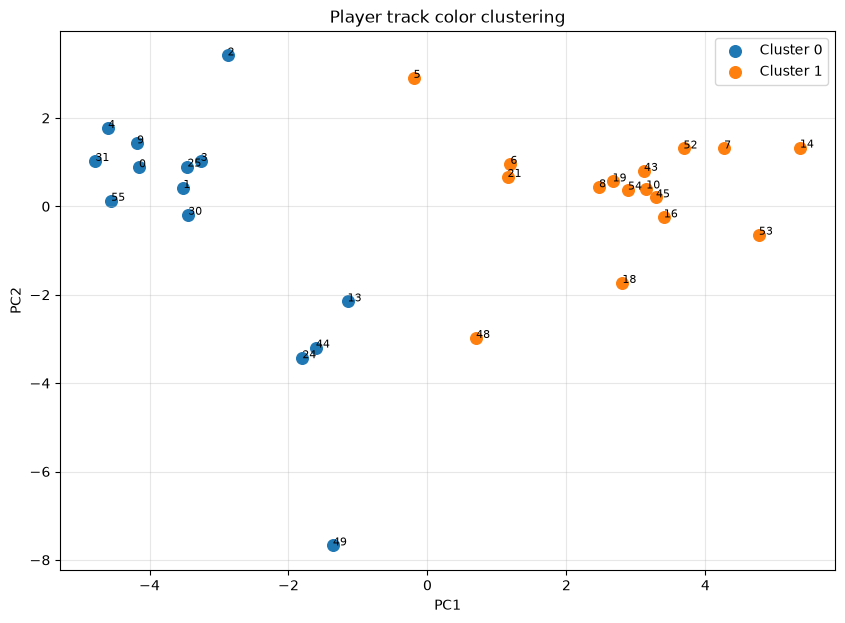

In [23]:
plt.figure(
    figsize=(10, 7)
)

for cluster_id in sorted(
    pca_df["cluster"].unique()
):

    subset = (
        pca_df[
            pca_df["cluster"]
            == cluster_id
        ]
    )

    plt.scatter(
        subset["pc1"],
        subset["pc2"],
        label=f"Cluster {cluster_id}",
        s=70,
    )

for _, row in pca_df.iterrows():

    plt.text(
        row["pc1"],
        row["pc2"],
        str(
            int(
                row["track_id"]
            )
        ),
        fontsize=8,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Player track color clustering"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

Funzione representative crop

In [24]:
def get_representative_crop(
    track_id
):

    rows = (
        tracks_df[
            tracks_df["track_id"]
            == track_id
        ]
        .sort_values(
            "confidence",
            ascending=False
        )
    )

    for _, row in rows.iterrows():

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        if crop is not None:
            return crop

    return None

Galleria di tutti i Track

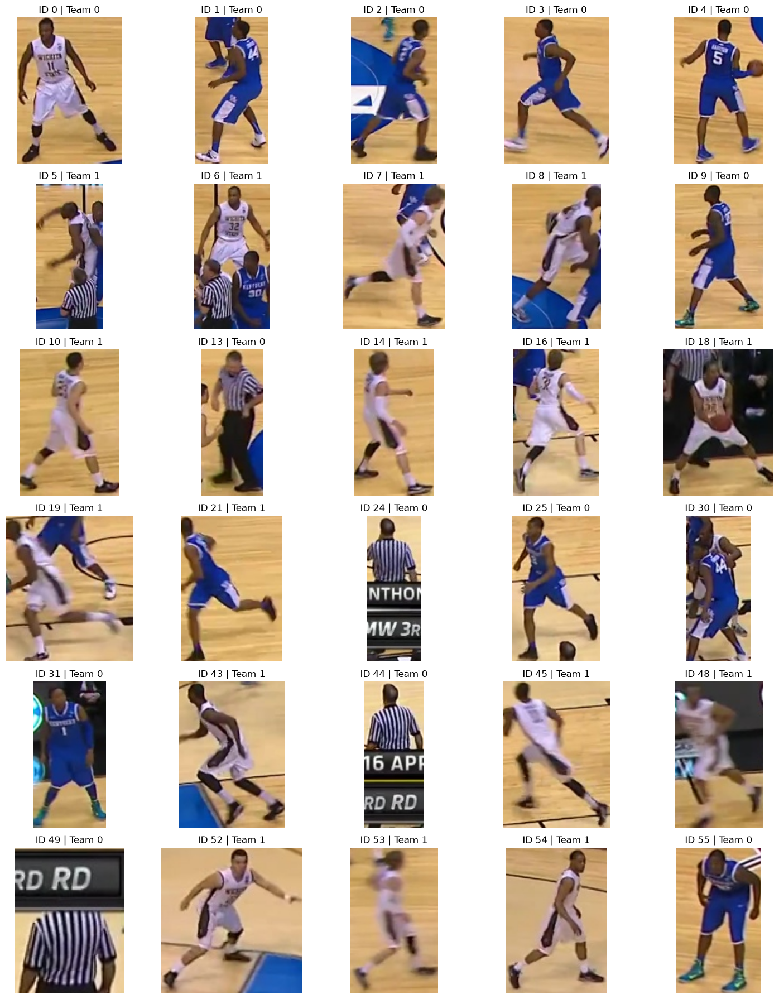

In [25]:
cluster_table = (
    player_track_features[
        ["cluster"]
    ]
    .reset_index()
)

n_tracks = len(
    cluster_table
)

cols = 5

rows = int(
    np.ceil(
        n_tracks / cols
    )
)

plt.figure(
    figsize=(
        15,
        rows * 3
    )
)

for i, row in cluster_table.iterrows():

    track_id = int(
        row["track_id"]
    )

    cluster_id = int(
        row["cluster"]
    )

    crop = get_representative_crop(
        track_id
    )

    ax = plt.subplot(
        rows,
        cols,
        i + 1
    )

    if crop is not None:

        ax.imshow(
            cv2.cvtColor(
                crop,
                cv2.COLOR_BGR2RGB
            )
        )

    ax.set_title(
        f"ID {track_id} | Team {cluster_id}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
def show_track_samples(
    track_id,
    n_samples=12
):

    track_data = (
        tracks_df[
            tracks_df["track_id"] == track_id
        ]
        .sort_values("frame")
        .copy()
    )

    if len(track_data) == 0:
        print("Track non trovato:", track_id)
        return

    indices = np.linspace(
        0,
        len(track_data) - 1,
        min(n_samples, len(track_data))
    ).astype(int)

    samples = track_data.iloc[
        indices
    ]

    cols = 4
    rows = int(
        np.ceil(
            len(samples) / cols
        )
    )

    plt.figure(
        figsize=(
            12,
            rows * 4
        )
    )

    for i, (_, row) in enumerate(
        samples.iterrows()
    ):

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        ax = plt.subplot(
            rows,
            cols,
            i + 1
        )

        if crop is not None:

            ax.imshow(
                cv2.cvtColor(
                    crop,
                    cv2.COLOR_BGR2RGB
                )
            )

        ax.set_title(
            f"ID {track_id}\nframe {frame_number}"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

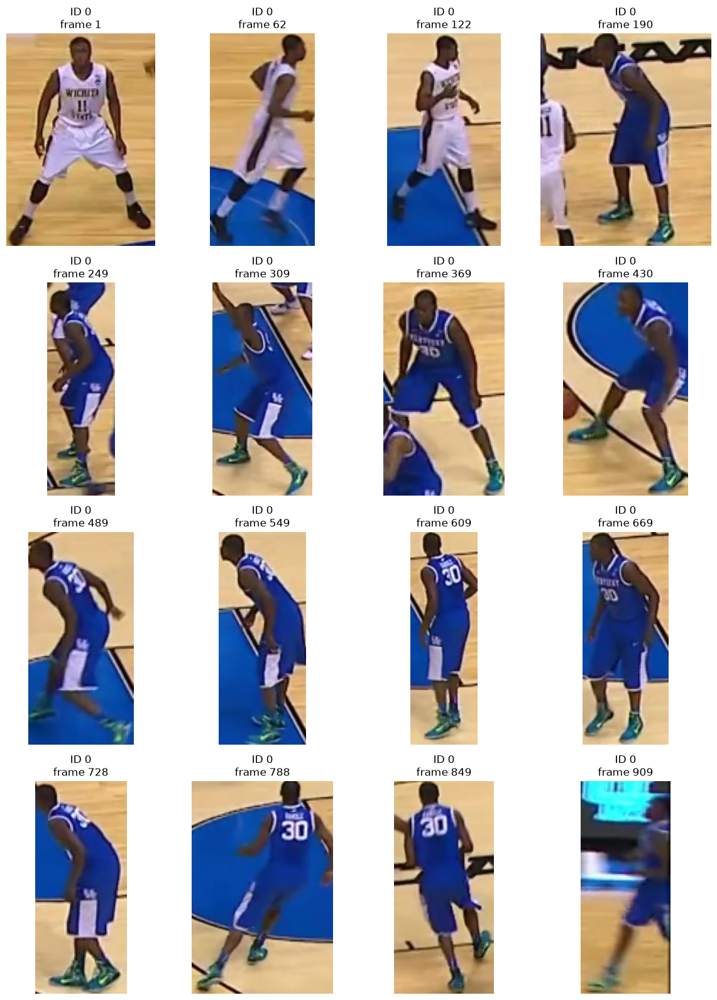

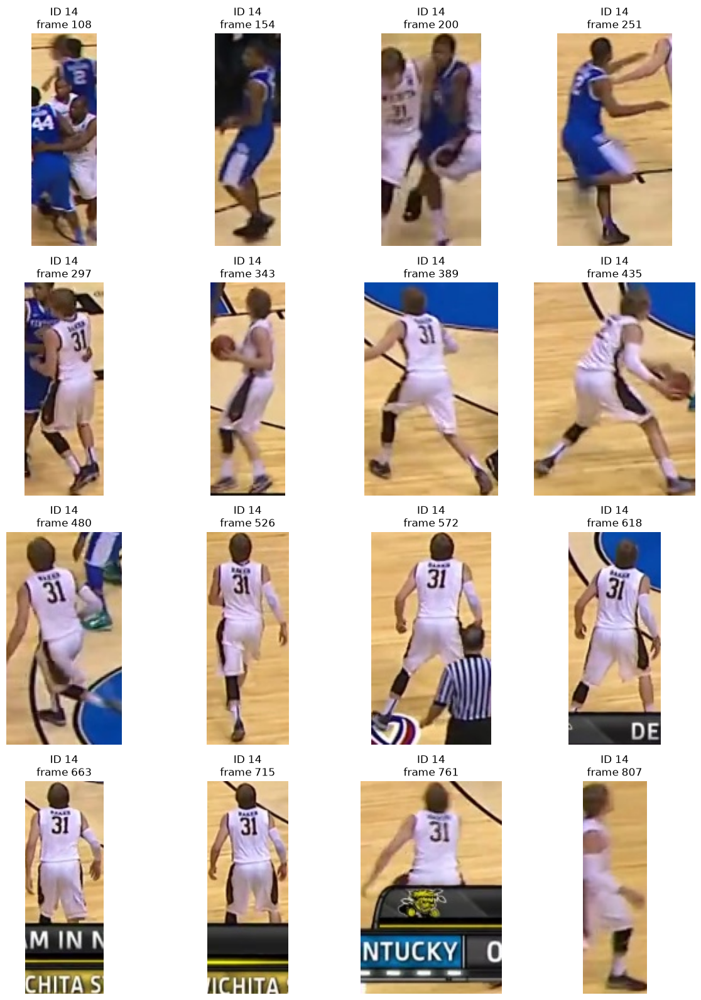

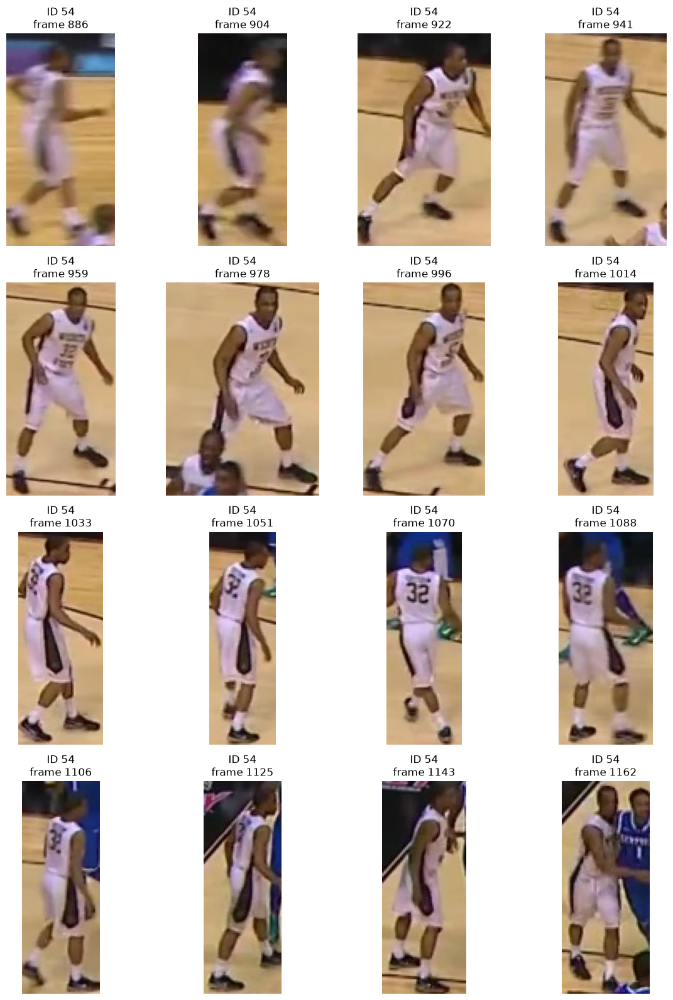

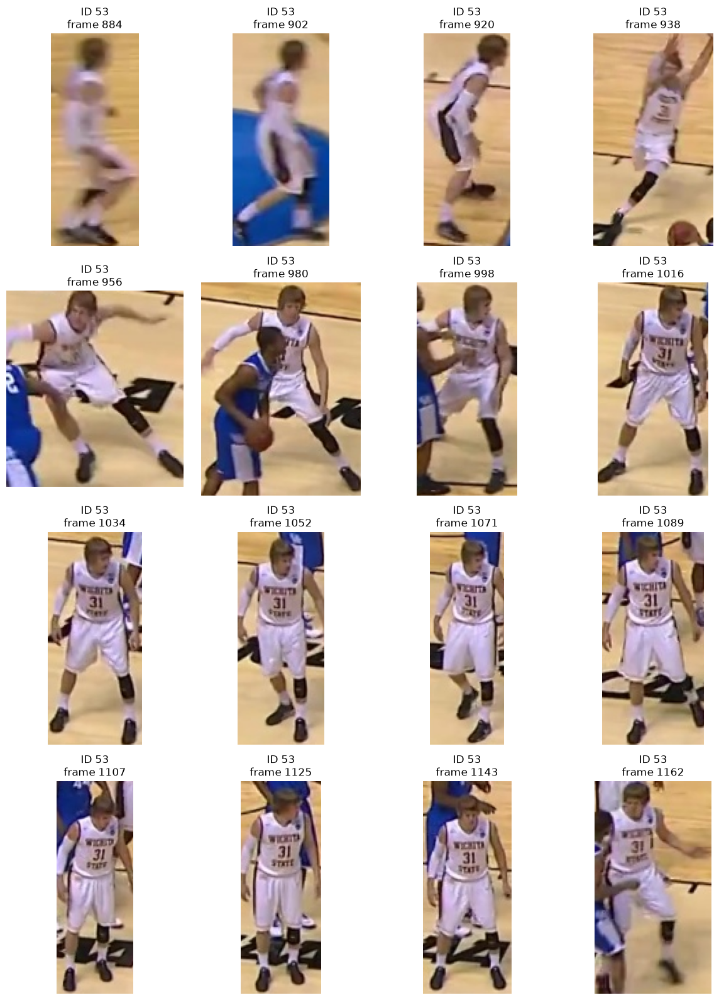

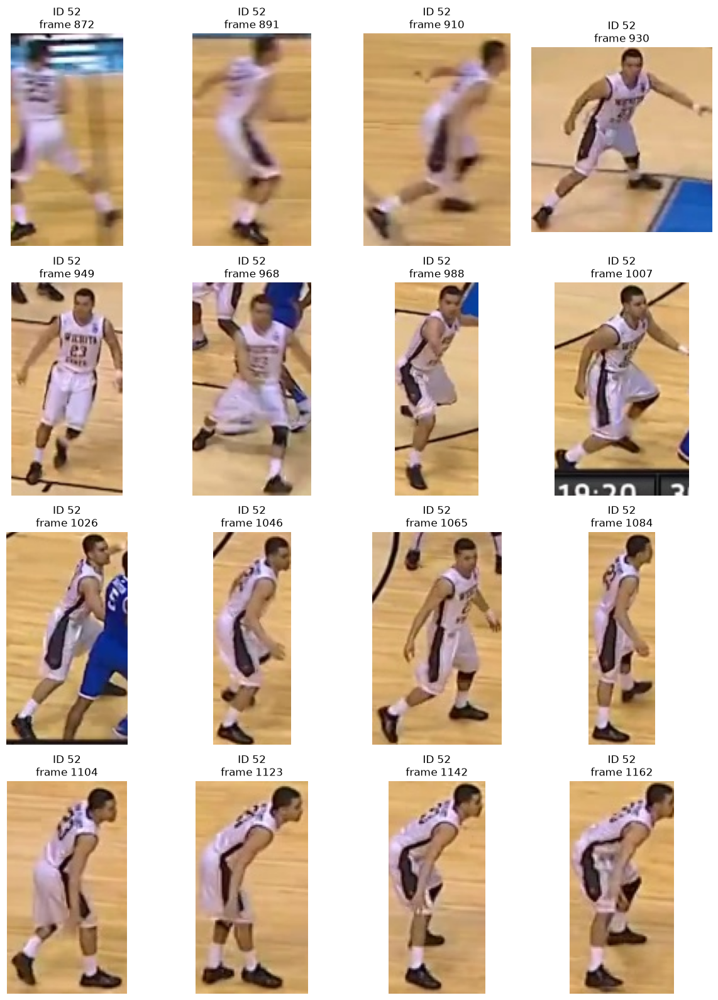

In [27]:
for track_id in track_ids_to_check[:5]:
    show_track_samples(
        track_id,
        n_samples=16
    )

## Visualizzazione cluster separati
Una galleria per cluster


CLUSTER 0
Track IDs: [0, 1, 2, 3, 4, 9, 13, 24, 25, 30, 31, 44, 49, 55]


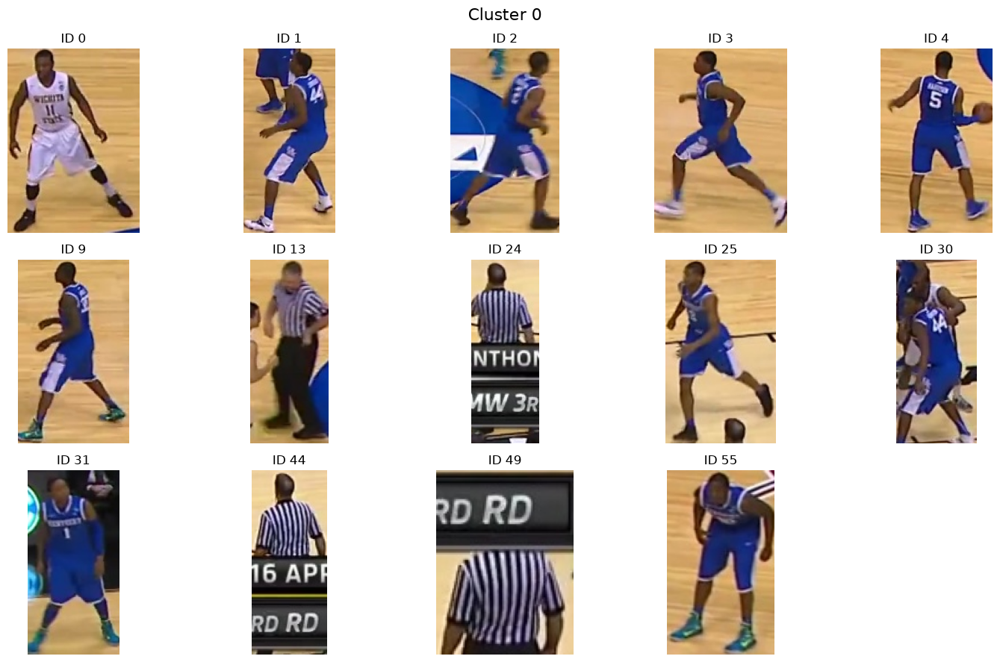


CLUSTER 1
Track IDs: [5, 6, 7, 8, 10, 14, 16, 18, 19, 21, 43, 45, 48, 52, 53, 54]


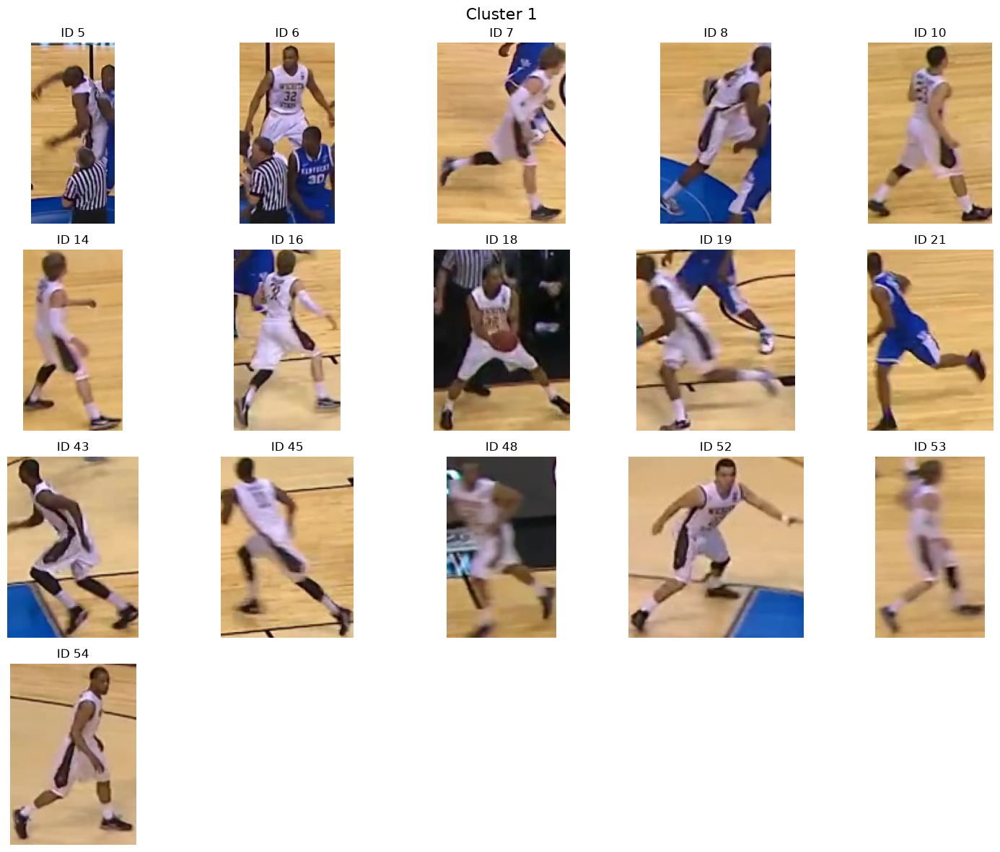

In [28]:
for cluster_id in sorted(
    cluster_table["cluster"].unique()
):

    track_ids = (
        cluster_table[
            cluster_table["cluster"]
            == cluster_id
        ]["track_id"]
        .tolist()
    )

    print(
        f"\nCLUSTER {cluster_id}"
    )

    print(
        "Track IDs:",
        track_ids
    )

    cols = 5

    rows = int(
        np.ceil(
            len(track_ids)
            / cols
        )
    )

    plt.figure(
        figsize=(
            15,
            max(
                3,
                rows * 3
            )
        )
    )

    for i, track_id in enumerate(
        track_ids
    ):

        crop = get_representative_crop(
            int(track_id)
        )

        ax = plt.subplot(
            rows,
            cols,
            i + 1
        )

        if crop is not None:

            ax.imshow(
                cv2.cvtColor(
                    crop,
                    cv2.COLOR_BGR2RGB
                )
            )

        ax.set_title(
            f"ID {int(track_id)}"
        )

        ax.axis("off")

    plt.suptitle(
        f"Cluster {cluster_id}",
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

Tabella track → cluster

In [29]:
team_baseline_df = (
    player_track_features[
        ["cluster", "num_samples"]
    ]
    .reset_index()
)

team_baseline_df[
    "visual_class"
] = (
    "team_"
    + team_baseline_df[
        "cluster"
    ].astype(str)
)

display(
    team_baseline_df.sort_values(
        [
            "cluster",
            "track_id"
        ]
    )
)

,track_id,cluster,num_samples,visual_class
0,0,0,25,team_0
1,1,0,24,team_0
2,2,0,25,team_0
3,3,0,25,team_0
4,4,0,25,team_0
9,9,0,25,team_0
11,13,0,22,team_0
17,24,0,7,team_0
18,25,0,24,team_0
19,30,0,3,team_0


Aggiungo Arbitri

In [30]:
print(
    "Referee non ancora assegnati.",
    "Prima identificare manualmente i track referee dalle gallerie."
)

Referee non ancora assegnati. Prima identificare manualmente i track referee dalle gallerie.


Salva CSV

In [31]:
TEAM_CSV = (
    OUTPUT_DIR
    / "track_visual_clusters.csv"
)

team_baseline_df.to_csv(
    TEAM_CSV,
    index=False
)

print(
    "Saved:",
    TEAM_CSV
)

print(
    "Exists:",
    TEAM_CSV.exists()
)

Saved: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/botsort_reid/team_classification/v_00HRwkvvjtQ_c001/track_visual_clusters.csv
Exists: True


Integrare il cluster nel tracking originale

In [32]:
tracks_with_cluster_df = (
    tracks_df
    .merge(
        team_baseline_df[
            [
                "track_id",
                "cluster",
                "visual_class"
            ]
        ],
        on="track_id",
        how="left",
    )
)

display(
    tracks_with_cluster_df.head()
)

,frame,track_id,x1,y1,x2,y2,confidence,class_id,cluster,visual_class
0,1,0,439.375305,266.328979,558.552917,436.577148,0.938461,0,0.0,team_0
1,1,1,971.564453,389.879883,1049.835327,605.411072,0.915086,0,0.0,team_0
2,1,2,637.455872,419.139099,764.137878,627.321350,0.870535,0,0.0,team_0
3,1,3,990.353394,290.022278,1052.396118,495.324768,0.847963,0,0.0,team_0
4,1,4,644.804443,272.780945,756.591797,430.809998,0.823956,0,0.0,team_0


Controllo

Salva tracking arricchito

In [37]:
ENRICHED_TRACKS_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_tracks_with_visual_cluster.csv"
)

tracks_with_cluster_df.to_csv(
    ENRICHED_TRACKS_CSV,
    index=False
)

print(
    "Saved:",
    ENRICHED_TRACKS_CSV
)

print(
    "Exists:",
    ENRICHED_TRACKS_CSV.exists()
)

Saved: /content/drive/MyDrive/basketball-thesis/experiments/team_classification/v_00HRwkvvjtQ_c001/v_00HRwkvvjtQ_c001_tracks_with_visual_cluster.csv
Exists: True


## Risultato BoT-SORT + ReID

È stata applicata la pipeline di classificazione visiva delle squadre alle
tracce prodotte da BoT-SORT + ReID.

La pipeline comprende:

1. estrazione delle bounding box dei giocatori;
2. selezione della regione del torso;
3. estrazione di feature colore HSV/LAB;
4. aggregazione temporale delle feature per track;
5. clustering unsupervised in due gruppi;
6. analisi della consistenza temporale del cluster;
7. visualizzazione dei track e individuazione di eventuali referee o ID switch;
8. salvataggio della classe visiva associata al tracking.

### Obiettivo del confronto

I risultati verranno confrontati con quelli ottenuti sulle tracce ByteTrack
per verificare se la maggiore continuità temporale di BoT-SORT + ReID
produce una classificazione di squadra più coerente.

Eventuali track contenenti giocatori appartenenti a squadre diverse
costituiscono evidenza di residual identity switch del tracker.